# SLM Classification Evaluation - Results Visualization
Compara runs de evaluacion priorizando Macro-F1 como metrica principal de seleccion.

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Carga automatica de resultados disponibles
result_files = sorted(Path('.').glob('classification_results_20260321_163539.json'))
if not result_files:
    raise FileNotFoundError('No se encontraron archivos classification_results_*.json en este directorio.')

# Para comparar visualmente, usa los 2 mas recientes; si solo hay uno, usa uno
selected = result_files[-2:] if len(result_files) >= 2 else result_files
FILES = {f'Run {i+1} ({p.stem.split("_")[-1]})': str(p) for i, p in enumerate(selected)}

runs = {}
for label, path in FILES.items():
    with open(path, encoding='utf-8') as f:
        runs[label] = json.load(f)

print('Runs cargados:', list(runs.keys()))
print(f'Modelos por run: {len(runs[list(runs.keys())[0]]["results"])}')

Runs cargados: ['Run 1 (163539)']
Modelos por run: 10


## 1 - Resumen por modelo (seleccion por Macro-F1)

In [4]:
for run_label, data in runs.items():
    rows = []
    for r in data['results']:
        rows.append({
            'Modelo': r['model_name'],
            'Accuracy': r.get('accuracy', 0.0),
            'F1 weighted': r.get('f1_score', 0.0),
            'Macro-F1': r.get('macro_f1', r.get('f1_score', 0.0)),
            'Unknown %': 100 * r.get('unknown_rate', 0.0),
            'Tiempo/muestra (s)': r['avg_time_per_sample'],
        })

    df = pd.DataFrame(rows).sort_values('Macro-F1', ascending=False).set_index('Modelo')
    print(f'\n=== {run_label} ===')
    display(
        df.style
          .format({
              'Accuracy': '{:.4f}',
              'F1 weighted': '{:.4f}',
              'Macro-F1': '{:.4f}',
              'Unknown %': '{:.2f}%',
              'Tiempo/muestra (s)': '{:.3f}'
          })
          .background_gradient(cmap='YlGn', subset=['Macro-F1'])
    )


=== Run 1 (163539) ===


,Accuracy,F1 weighted,Macro-F1,Unknown %,Tiempo/muestra (s)
Modelo,,,,,
Gemma-2-9B-it,0.7720,0.7656,0.7603,0.00%,3.212
Phi-4,0.7440,0.7351,0.7275,0.00%,5.273
Qwen2.5-14B-Instruct,0.7520,0.7334,0.7209,0.00%,5.900
Qwen2.5-7B-Instruct,0.7040,0.6809,0.6676,0.00%,0.156
Mistral-7B-Instruct,0.6760,0.6691,0.6654,0.40%,0.223
Llama-3.1-8B-Instruct,0.6480,0.6339,0.6276,0.00%,5.562
Phi-3.5-mini-instruct,0.6160,0.5941,0.5851,0.40%,0.144
Qwen2.5-3B-Instruct,0.5640,0.5672,0.5484,0.40%,0.130
Llama-3.2-3B-Instruct,0.5760,0.5536,0.5443,0.00%,0.121


## 2 - Macro-F1 por modelo

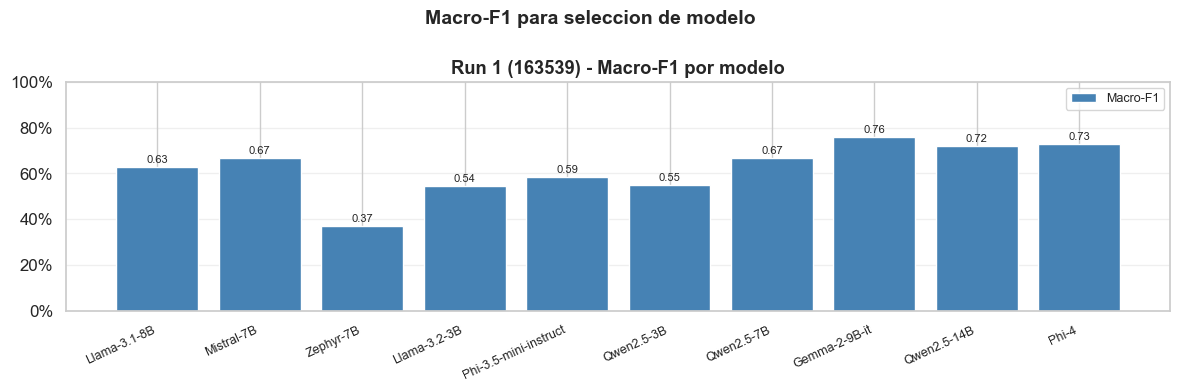

In [5]:
fig, axes = plt.subplots(len(runs), 1, figsize=(12, 4 * len(runs)), sharex=False, sharey=False)
if len(runs) == 1:
    axes = [axes]

for ax, (run_label, data) in zip(axes, runs.items()):
    models = [r['model_name'].replace('-Instruct', '').replace('-Chat', '') for r in data['results']]
    macro_f1 = [r.get('macro_f1', r.get('f1_score', 0.0)) for r in data['results']]

    x = np.arange(len(models))
    bars_mf1 = ax.bar(x, macro_f1, label='Macro-F1', color='steelblue')

    for bar in bars_mf1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(f'{run_label} - Macro-F1 por modelo', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha='right', fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Macro-F1 para seleccion de modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_macro_f1_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 - Recall por categoria (heatmap)

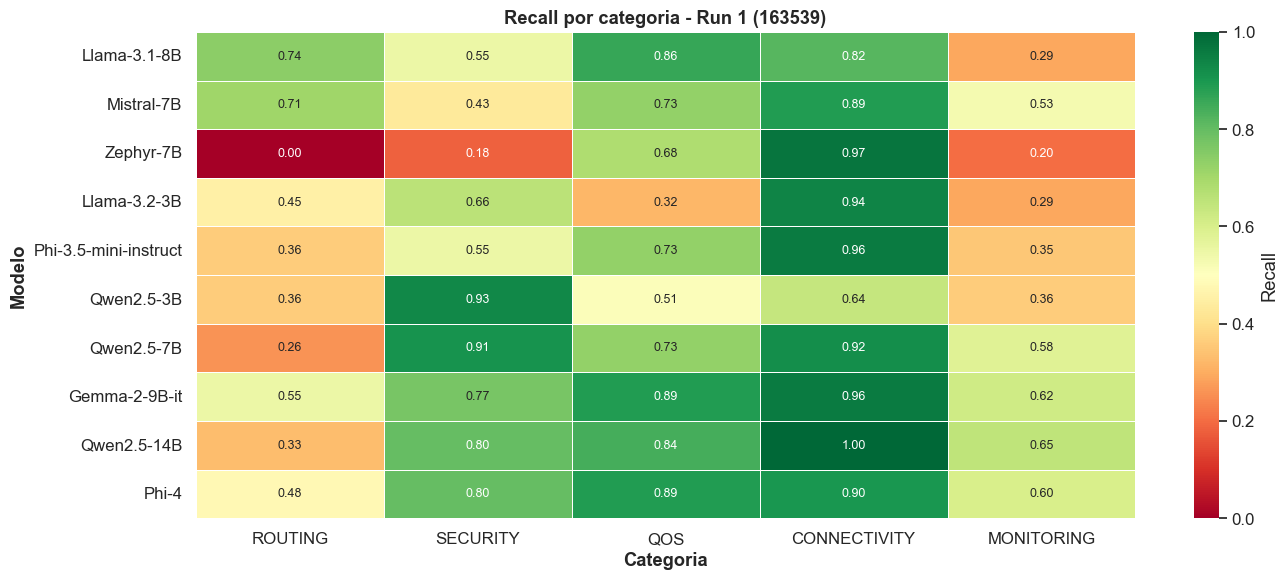

In [6]:
import re

def parse_recall_per_category(report_str, categories):
    """Extrae recall por categoria del classification_report string."""
    recalls = {}
    for cat in categories:
        pattern = rf'^\s*{re.escape(cat)}\s+[\d.]+\s+([\d.]+)'
        m = re.search(pattern, report_str, re.MULTILINE)
        recalls[cat] = float(m.group(1)) if m else 0.0
    return recalls

fig, axes = plt.subplots(len(runs), 1, figsize=(14, 6 * len(runs)))
if len(runs) == 1:
    axes = [axes]

for ax, (run_label, data) in zip(axes, runs.items()):
    categories = data['categories']
    models = [r['model_name'].replace('-Instruct','').replace('-Chat','') for r in data['results']]
    matrix = []
    for r in data['results']:
        recalls = parse_recall_per_category(r['classification_report'], categories)
        matrix.append([recalls[c] for c in categories])

    df_heat = pd.DataFrame(matrix, index=models, columns=categories)
    sns.heatmap(df_heat, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=0, vmax=1, linewidths=0.5, cbar_kws={'label': 'Recall'}, annot_kws={'fontsize': 9})
    ax.set_title(f'Recall por categoria - {run_label}', fontweight='bold')
    ax.set_xlabel('Categoria', fontweight='bold')
    ax.set_ylabel('Modelo', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 - Matrices de confusion por modelo (normalizada por fila + conteos)

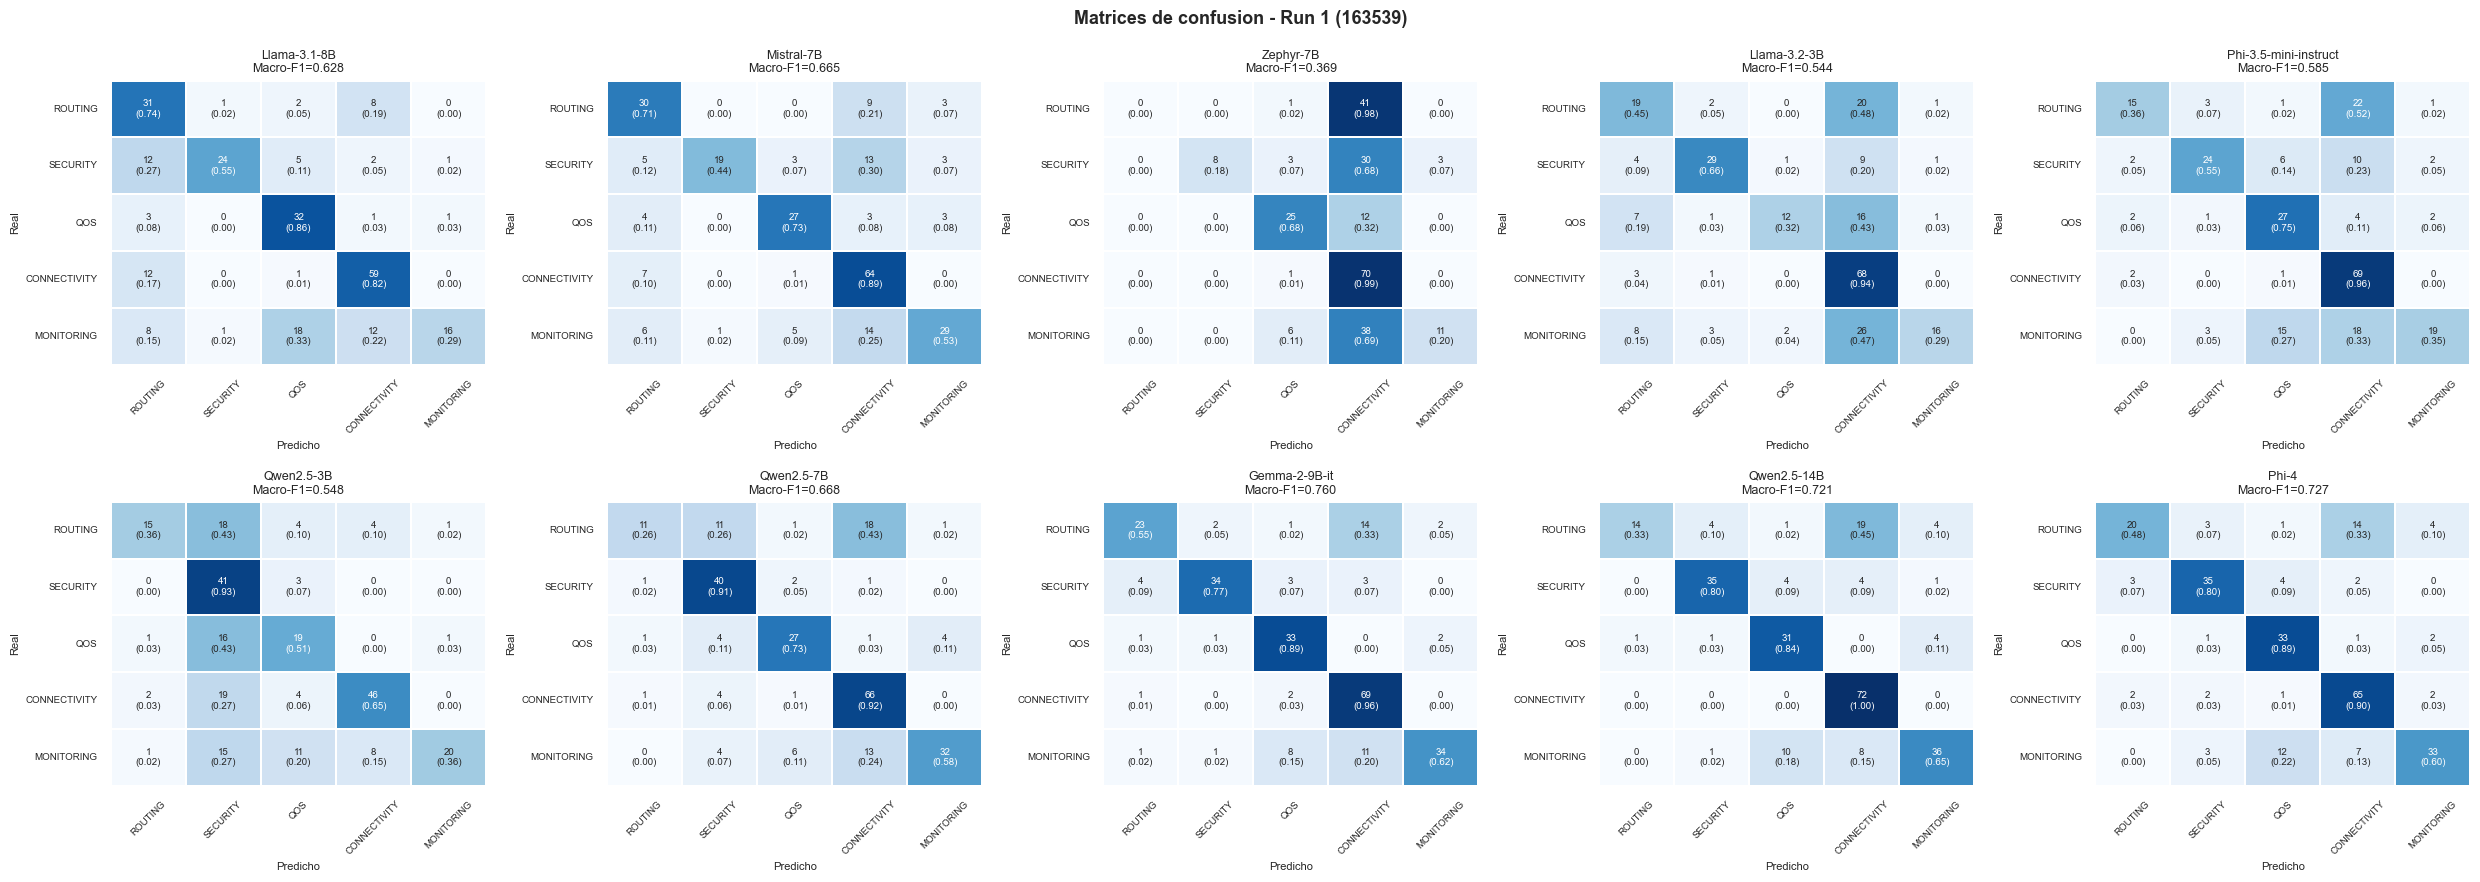

In [7]:
for run_label, data in runs.items():
    categories = data['categories']
    n = len(data['results'])
    
    # Grid flexible: 2 filas para 10 modelos, 1 fila para 5, etc.
    cols = min(5, n)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
    if n == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    else:
        axes = [ax for row in axes for ax in row]
    
    fig.suptitle(f'Matrices de confusion - {run_label}', fontsize=13, fontweight='bold')

    for ax, r in zip(axes[:n], data['results']):
        cm = np.array(r['confusion_matrix'])
        cm_norm = np.array(r.get('confusion_matrix_normalized', []), dtype=float)
        if cm_norm.size == 0:
            row_sums = cm.sum(axis=1, keepdims=True)
            cm_norm = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums > 0)

        annot = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f'{cm[i, j]}\n({cm_norm[i, j]:.2f})'

        sns.heatmap(
            cm_norm,
            ax=ax,
            annot=annot,
            fmt='',
            cmap='Blues',
            xticklabels=categories,
            yticklabels=categories,
            vmin=0,
            vmax=1,
            cbar=False,
            linewidths=0.3,
            annot_kws={'size': 7}
        )
        model_short = r['model_name'].replace('-Instruct', '').replace('-Chat', '')
        ax.set_title(
            f"{model_short}\nMacro-F1={r.get('macro_f1', r.get('f1_score', 0.0)):.3f}",
            fontsize=9
        )
        ax.set_xlabel('Predicho', fontsize=8)
        ax.set_ylabel('Real', fontsize=8)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', rotation=0, labelsize=7)
    
    # Ocultar ejes vacios
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    safe_label = run_label.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    plt.savefig(f'plot_confusion_{safe_label}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5 - Ranking final por Macro-F1


=== Ranking Run 1 (163539) ===


,Modelo,Macro-F1,Tiempo/muestra (s)
0,Gemma-2-9B-it,0.7603,3.212
1,Phi-4,0.7275,5.273
2,Qwen2.5-14B,0.7209,5.900
3,Qwen2.5-7B,0.6676,0.156
4,Mistral-7B,0.6654,0.223
5,Llama-3.1-8B,0.6276,5.562
6,Phi-3.5-mini-instruct,0.5851,0.144
7,Qwen2.5-3B,0.5484,0.130
8,Llama-3.2-3B,0.5443,0.121
9,Zephyr-7B,0.3688,0.376


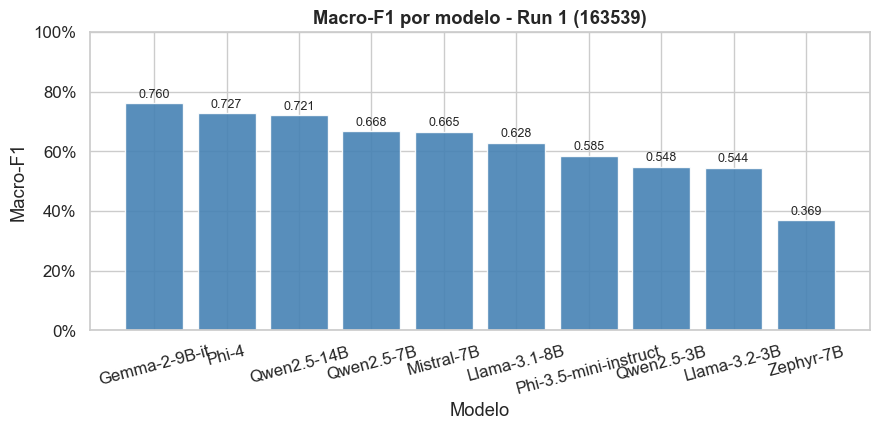

In [8]:
for run_label, data in runs.items():
    rows = []
    for r in data['results']:
        rows.append({
            'Modelo': r['model_name'].replace('-Instruct', '').replace('-Chat', ''),
            'Macro-F1': r.get('macro_f1', r.get('f1_score', 0.0)),
            'Tiempo/muestra (s)': r['avg_time_per_sample'],
        })

    df_rank = pd.DataFrame(rows).sort_values('Macro-F1', ascending=False).reset_index(drop=True)
    print(f'\n=== Ranking {run_label} ===')
    display(
        df_rank.style
        .format({
            'Macro-F1': '{:.4f}',
            'Tiempo/muestra (s)': '{:.3f}'
        })
        .background_gradient(cmap='YlGn', subset=['Macro-F1'])
    )

    fig, ax = plt.subplots(figsize=(9, 4.5))
    bars = ax.bar(df_rank['Modelo'], df_rank['Macro-F1'], color='steelblue', alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(f'Macro-F1 por modelo - {run_label}', fontweight='bold')
    ax.set_xlabel('Modelo')
    ax.set_ylabel('Macro-F1')
    ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    safe_label = run_label.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    plt.savefig(f'plot_macro_f1_ranking_{safe_label}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6 - Velocidad de inferencia (tiempo promedio por muestra)

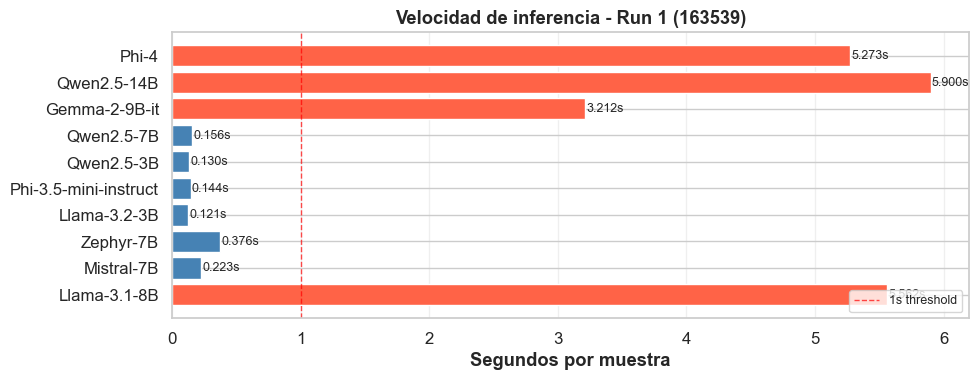

In [9]:
fig, axes = plt.subplots(len(runs), 1, figsize=(10, 4 * len(runs)))
if len(runs) == 1:
    axes = [axes]

for ax, (run_label, data) in zip(axes, runs.items()):
    models = [r['model_name'].replace('-Instruct','').replace('-Chat','') for r in data['results']]
    times  = [r['avg_time_per_sample'] for r in data['results']]
    colors_bar = ['tomato' if t > 1.0 else 'steelblue' for t in times]
    bars = ax.barh(models, times, color=colors_bar)
    for bar, t in zip(bars, times):
        ax.text(t + 0.01, bar.get_y() + bar.get_height()/2,
                f'{t:.3f}s', va='center', fontsize=9)
    ax.set_xlabel('Segundos por muestra', fontweight='bold')
    ax.set_title(f'Velocidad de inferencia - {run_label}', fontweight='bold')
    ax.axvline(1.0, color='red', linestyle='--', linewidth=1, label='1s threshold', alpha=0.7)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_inference_speed.png', dpi=150, bbox_inches='tight')
plt.show()